<a href="https://colab.research.google.com/github/WayneNganju/D-10-Lab-on-Regression/blob/main/D10_invoice_payment_risk_classification_~_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D10: Invoice Payment Risk Classification

## Team Introduction

This notebook was completed by Group D10 using the `invoice_payment_risk.csv` dataset. The aim of the analysis is to classify invoices as `On-Time`, `Late`, or `Severely Late` using client, invoice, payment-history, guarantee, and economic information.

The target variable is `payment_risk_category`. The analysis follows a structured classification workflow, starting with data understanding and exploratory analysis, then moving through train/test splitting, feature selection, preprocessing, model comparison, diagnostics, tuning, explainability, and model persistence.

| Team Member | ID Number | Primary Contribution |
|---|---:|---|
| Wayne Nganju | 146832 | As team leader, I completed the notebook setup, data loading, initial data understanding, exploratory data analysis, and stratified train/test split.<br><br>I coordinated work handovers and completed the final integration and review of the notebook. |
| Vanessa Warui | 152142 | Vanessa completed feature selection using chi-square tests, ANOVA, mutual information, and RFECV.<br><br>She provided the selected features for the preprocessing stage. |
| Natasha Njoroge | 150567 | Natasha built the preprocessing pipeline.<br><br>Her work included structural-missingness handling, categorical encoding, numeric scaling, and resampling analysis. |
| Ibrahim Omoi | 165042 | Ibrahim compared the classification models using stratified cross-validation.<br><br>He also evaluated the candidate models using the held-out test dataset. |
| Melvin Muriithi | 152384 | Melvin completed classification diagnostics, hyperparameter tuning, model explainability, and model persistence.<br><br>He used the selected model and shared preprocessing pipeline for these stages. |

The work was completed sequentially so that each stage used the appropriate output from the previous stage. This approach prevented data leakage, especially during feature selection, preprocessing, resampling, cross-validation, and test evaluation.

The final model was selected using macro F1-score because the payment-risk categories were imbalanced. This ensured that `On-Time`, `Late`, and `Severely Late` invoices were given equal importance during model evaluation.

## 1. Environment Setup and Imports

This section prepares the Python environment and imports the libraries needed for the classification analysis.

A fixed random state will be used so that the train/test split, resampling methods, and model results can be reproduced. The `imbalanced-learn` library will be used later to handle class imbalance safely within the modeling pipeline.

In [1]:
%pip install -q imbalanced-learn

In [2]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "payment_risk_category"

np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print(f"Python version: {sys.version.split()[0]}")
print(f"Target variable: {TARGET}")
print(f"Train/test split ratio: {1 - TEST_SIZE:.0%}/{TEST_SIZE:.0%}")

Python version: 3.13.15
Target variable: payment_risk_category
Train/test split ratio: 80%/20%


## 2. Data Loading and Initial Data Understanding

The invoice payment-risk dataset is loaded directly from the course repository. This allows the notebook to run without relying on temporary file uploads in Google Colab.

The dataset will be examined to confirm its shape, columns, data types, and target variable before exploratory data analysis begins.

In [3]:
DATA_URL = (
    "https://raw.githubusercontent.com/course-files/RegressionAndClassification/main/data/invoice_payment_risk.csv"
)

invoice_data = pd.read_csv(
    DATA_URL,
    encoding="utf-8"
)

if TARGET not in invoice_data.columns:
    raise KeyError(
        f"Expected target '{TARGET}' was not found. "
        f"Available columns: {invoice_data.columns.tolist()}"
    )

print(
    f"Dataset shape: {invoice_data.shape[0]:,} rows "
    f"and {invoice_data.shape[1]:,} columns"
)

display(invoice_data.head())

Dataset shape: 1,500 rows and 16 columns


,invoice_id,client_industry,client_credit_rating,client_company_size,payment_method,has_dispute_history,collateral_or_guarantee,payment_terms_days,invoice_amount_kes,client_relationship_years,prior_late_payments_count,discount_offered_pct,days_outstanding_avg_historical,guarantee_value_kes,economic_sector_growth_rate_pct,payment_risk_category
0,1,Technology,Good,Large,Bank Transfer,Yes,No,45,256337.0,1.9,1,2.73,22.2,NaN,4.87,Late
1,2,Manufacturing,Fair,Small,Bank Transfer,No,No,60,608908.0,6.8,1,2.10,34.0,NaN,2.09,On-Time
2,3,Technology,Good,Medium,Bank Transfer,Yes,No,15,499261.0,5.0,1,2.19,24.6,NaN,4.80,On-Time
3,4,Technology,Good,Medium,Mobile Money,No,No,15,219366.0,8.1,0,1.30,10.3,NaN,4.24,On-Time
4,5,Retail,Excellent,Large,Cheque,Yes,No,45,288282.0,4.5,0,3.26,12.9,NaN,1.42,On-Time


In [4]:
invoice_data.info()

print("\nColumn names:")
print(invoice_data.columns.tolist())

print(f"\nTarget classes in '{TARGET}':")
print(
    invoice_data[TARGET]
    .value_counts(dropna=False)
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   invoice_id                       1500 non-null   int64  
 1   client_industry                  1500 non-null   object 
 2   client_credit_rating             1500 non-null   object 
 3   client_company_size              1500 non-null   object 
 4   payment_method                   1500 non-null   object 
 5   has_dispute_history              1500 non-null   object 
 6   collateral_or_guarantee          1500 non-null   object 
 7   payment_terms_days               1500 non-null   int64  
 8   invoice_amount_kes               1500 non-null   float64
 9   client_relationship_years        1500 non-null   float64
 10  prior_late_payments_count        1500 non-null   int64  
 11  discount_offered_pct             1500 non-null   float64
 12  days_outstanding_avg

**Initial Data Understanding**

The dataset has 1,500 invoice records and 16 columns. The target variable is `payment_risk_category`, which classifies each invoice as `On-Time`, `Late`, or `Severely Late`.

The dataset contains an identifier column called `invoice_id`, six categorical predictor variables, and eight numeric predictor variables. The categorical variables describe the client's industry, credit rating, company size, payment method, dispute history, and guarantee status. The numeric variables describe payment terms, invoice amount, client relationship length, previous late payments, discount offered, historical payment behaviour, guarantee value, and economic sector growth.

The target classes are imbalanced. There are 975 `On-Time` invoices, 375 `Late` invoices, and 150 `Severely Late` invoices. This means that `On-Time` invoices make up 65% of the dataset, while `Severely Late` invoices make up only 10%. This imbalance will be considered when splitting the data, comparing models, and selecting evaluation metrics.

The `guarantee_value_kes` column has 538 recorded values and 962 missing values. The reason for these missing values will be investigated during exploratory data analysis before selecting a preprocessing method. The `invoice_id` column is an identifier and will not be used as a predictive feature after the train/test split.

## 3. Exploratory Data Analysis

Exploratory data analysis is carried out to understand the invoice data before building any classification model. This section examines class balance, variable types, missing values, numeric distributions, possible outliers, and relationships between predictors and payment-risk categories.

The original `invoice_data` DataFrame is used for exploratory analysis only. No variables are removed, transformed, encoded, resampled, or used to train a model at this stage.

### Class Balance of Payment Risk Categories

The class balance of `payment_risk_category` is examined before modeling. This is important because the target categories are not equally represented.

A model that predicts the most common category, `On-Time`, for every invoice could appear accurate while failing to identify `Late` and `Severely Late` invoices. Therefore, class balance will guide the later train/test split, resampling approach, cross-validation method, and evaluation metrics.

,count,percentage
payment_risk_category,,
On-Time,975,65.0
Late,375,25.0
Severely Late,150,10.0


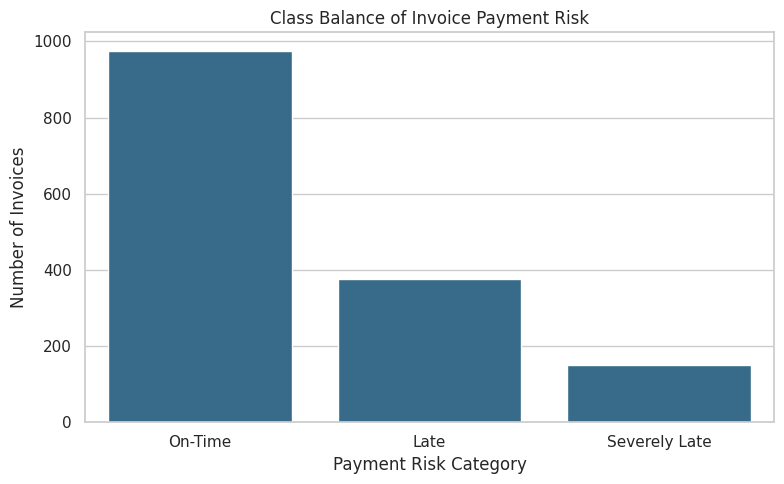

In [5]:
CLASS_ORDER = [
    "On-Time",
    "Late",
    "Severely Late",
]

class_counts = (
    invoice_data[TARGET]
    .value_counts()
    .reindex(CLASS_ORDER)
)

class_percentages = (
    invoice_data[TARGET]
    .value_counts(normalize=True)
    .reindex(CLASS_ORDER)
    .mul(100)
)

class_summary = pd.DataFrame(
    {
        "count": class_counts,
        "percentage": class_percentages,
    }
)

display(class_summary.round(2))

plt.figure(figsize=(8, 5))

sns.countplot(
    data=invoice_data,
    x=TARGET,
    order=CLASS_ORDER,
    color="#2A6F97"
)

plt.title("Class Balance of Invoice Payment Risk")
plt.xlabel("Payment Risk Category")
plt.ylabel("Number of Invoices")

plt.tight_layout()
plt.show()

**Interpretation of Class Balance**

The `On-Time` category has 975 invoices, representing 65% of the dataset. The `Late` category has 375 invoices, representing 25% of the dataset. The `Severely Late` category has 150 invoices, representing 10% of the dataset.

This shows that the target variable is imbalanced. `Severely Late` is the minority class, but it is important because invoices in this category may require earlier collection action or closer credit review.

Accuracy alone will not be enough to evaluate models because a model could achieve 65% accuracy by predicting every invoice as `On-Time`. The later modeling stages will use stratified splitting, stratified cross-validation, resampling methods, and macro F1-score so that all three payment-risk categories are considered fairly.

### Variable Types and Missing Values

The dataset contains numeric and categorical variables. Numeric variables include invoice amounts, payment terms, client relationship length, payment history, discount percentages, historical payment behaviour, guarantee value, and economic sector growth.

Categorical variables include client industry, client credit rating, client company size, payment method, dispute history, and collateral or guarantee status.

Missing values are examined before preprocessing because the reason a value is missing may be important. In particular, missing guarantee values may be connected to whether an invoice has collateral or a guarantee.

In [6]:
numeric_cols = invoice_data.select_dtypes(
    include=np.number
).columns.tolist()

categorical_cols = invoice_data.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_predictor_cols = [
    column for column in numeric_cols
    if column != "invoice_id"
]

categorical_predictor_cols = [
    column for column in categorical_cols
    if column != TARGET
]

print("Numeric predictor columns:")
print(numeric_predictor_cols)

print("\nCategorical predictor columns:")
print(categorical_predictor_cols)

missingness = (
    invoice_data.isna()
    .sum()
    .to_frame("missing_count")
    .assign(
        missing_percentage=lambda frame: (
            frame["missing_count"] / len(invoice_data) * 100
        )
    )
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

display(missingness.round(2))

Numeric predictor columns:
['payment_terms_days', 'invoice_amount_kes', 'client_relationship_years', 'prior_late_payments_count', 'discount_offered_pct', 'days_outstanding_avg_historical', 'guarantee_value_kes', 'economic_sector_growth_rate_pct']

Categorical predictor columns:
['client_industry', 'client_credit_rating', 'client_company_size', 'payment_method', 'has_dispute_history', 'collateral_or_guarantee']


,missing_count,missing_percentage
guarantee_value_kes,962,64.13
invoice_id,0,0.00
client_credit_rating,0,0.00
client_industry,0,0.00
payment_method,0,0.00
has_dispute_history,0,0.00
collateral_or_guarantee,0,0.00
client_company_size,0,0.00
payment_terms_days,0,0.00
invoice_amount_kes,0,0.00


**Interpretation of Variable Types and Missing Values**

The dataset has eight numeric predictor variables and six categorical predictor variables. The `invoice_id` column is an identifier and will not be used as a predictive feature after the train/test split.

Only `guarantee_value_kes` has missing values. It has 962 missing values, representing 64.13% of all invoice records. All other predictor variables and the target variable have no missing values.

The large amount of missing values in `guarantee_value_kes` may be related to the `collateral_or_guarantee` variable. This relationship will be examined next to determine whether the missing values are structural, such as invoices without a collateral or guarantee value, or whether they may be random.

No missing values are filled at this stage. Any imputation or missing-value indicator will later be fitted on the training data only.

In [7]:
guarantee_value_status = pd.Series(
    np.where(
        invoice_data["guarantee_value_kes"].isna(),
        "Missing",
        "Recorded"
    ),
    index=invoice_data.index,
    name="guarantee_value_status"
)

guarantee_missingness_check = pd.crosstab(
    invoice_data["collateral_or_guarantee"],
    guarantee_value_status,
    margins=True
)

guarantee_missingness_check = guarantee_missingness_check.reindex(
    columns=["Recorded", "Missing", "All"],
    fill_value=0
)

guarantee_missingness_check.index.name = (
    "Collateral or Guarantee Status"
)

guarantee_missingness_check.columns.name = (
    "Guarantee Value Status"
)

display(guarantee_missingness_check)

Guarantee Value Status,Recorded,Missing,All
Collateral or Guarantee Status,,,
No,0,962,962
Yes,538,0,538
All,538,962,1500


**Interpretation of Guarantee Value Missingness**

The missing values in `guarantee_value_kes` are structural rather than random. All 962 invoices marked `No` under `collateral_or_guarantee` have a missing guarantee value, while all 538 invoices marked `Yes` have a recorded guarantee value.

This means that a missing guarantee value represents an invoice without collateral or a guarantee. The missing value is therefore meaningful information rather than an unknown value that occurred by chance.

During preprocessing, `guarantee_value_kes` will be handled using median imputation together with a missingness indicator. This will allow the classification model to use both the guarantee value and the fact that no guarantee was recorded.

### Distribution of Numeric Variables

The numeric predictor variables are examined using measures of central tendency and distribution. These include the minimum value, lower quartile, median, upper quartile, maximum value, mean, standard deviation, skewness, and kurtosis.

These measures help identify variables with unusual ranges, strong skewness, or extreme values. Such patterns may affect some classification models and may guide later preprocessing decisions.

In [8]:
q1 = invoice_data[numeric_predictor_cols].quantile(0.25)
q2 = invoice_data[numeric_predictor_cols].quantile(0.50)
q3 = invoice_data[numeric_predictor_cols].quantile(0.75)

iqr = q3 - q1

distribution_summary = pd.DataFrame(
    {
        "minimum": invoice_data[numeric_predictor_cols].min(),
        "q1_25%": q1,
        "median_q2_50%": q2,
        "q3_75%": q3,
        "maximum": invoice_data[numeric_predictor_cols].max(),
        "mean": invoice_data[numeric_predictor_cols].mean(),
        "standard_deviation": invoice_data[numeric_predictor_cols].std(),
        "skewness": invoice_data[numeric_predictor_cols].skew(),
        "kurtosis": invoice_data[numeric_predictor_cols].kurt(),
        "IQR": iqr,
        "lower_fence": q1 - 1.5 * iqr,
        "upper_fence": q3 + 1.5 * iqr,
    }
)

display(distribution_summary.round(2))

,minimum,q1_25%,median_q2_50%,q3_75%,maximum,mean,standard_deviation,skewness,kurtosis,IQR,lower_fence,upper_fence
payment_terms_days,15.00,30.00,45.00,45.00,90.00,41.86,21.25,0.87,0.20,15.00,7.50,67.50
invoice_amount_kes,10000.00,184176.50,304465.50,476821.00,1991781.00,362759.00,253468.62,1.49,3.29,292644.50,-254790.25,915787.75
client_relationship_years,0.20,2.90,4.80,7.80,25.00,5.83,4.06,1.41,2.71,4.90,-4.45,15.15
prior_late_payments_count,0.00,0.00,1.00,2.00,6.00,1.09,1.03,1.01,1.07,2.00,-3.00,5.00
discount_offered_pct,0.00,1.17,2.01,2.78,5.55,2.03,1.15,0.22,-0.42,1.61,-1.25,5.20
days_outstanding_avg_historical,0.00,16.30,23.55,31.20,78.00,24.90,11.88,0.85,1.09,14.90,-6.05,53.55
guarantee_value_kes,11787.12,140562.20,231544.36,387009.33,1487066.36,289827.08,224555.08,1.70,3.81,246447.12,-229108.48,756680.01
economic_sector_growth_rate_pct,-0.12,1.31,2.04,3.15,5.46,2.33,1.32,0.57,-0.69,1.84,-1.45,5.91


**Interpretation of Numeric Variable Distributions**

The numeric variables have different ranges and distribution patterns. `invoice_amount_kes` ranges from 10,000.00 KES to 1,991,781.00 KES and has a skewness of 1.49. This shows that invoice amounts are skewed to the right, meaning that most invoices have lower to moderate values while a smaller number have very high values.

`guarantee_value_kes` has a skewness of 1.70 and a kurtosis of 3.81 among invoices with a recorded guarantee value. This suggests that some guaranteed invoices have substantially higher guarantee values than others. The missing values in this variable are structurally related to invoices without collateral or a guarantee.

`client_relationship_years` and `prior_late_payments_count` are also positively skewed. This suggests that most clients have shorter business relationships and fewer prior late payments, while a smaller number have long client relationships or several late payments.

`discount_offered_pct` is approximately symmetric, with a skewness of 0.22. `economic_sector_growth_rate_pct` has a moderate positive skewness of 0.57 and includes negative values, which represent sectors with negative growth.

Since this is a classification problem, the target variable will not be transformed. The numeric predictor distributions will be handled later using preprocessing methods that are fitted on the training data only.

### Potential Outliers

The interquartile range (IQR) method is used to identify potential outliers in the numeric predictor variables.

A value is considered a potential outlier if it is below the lower fence or above the upper fence. The lower fence is calculated as $Q1 - 1.5 \times IQR$, while the upper fence is calculated as $Q3 + 1.5 \times IQR$.

Potential outliers will be investigated but will not be removed automatically. Large invoice amounts, long client relationships, high guarantee values, and a high number of late payments may be valid invoice records.

In [9]:
q1 = invoice_data[numeric_predictor_cols].quantile(0.25)
q3 = invoice_data[numeric_predictor_cols].quantile(0.75)

iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_mask = (
    (invoice_data[numeric_predictor_cols] < lower_fence)
    | (invoice_data[numeric_predictor_cols] > upper_fence)
)

outlier_summary = pd.DataFrame(
    {
        "potential_outlier_count": outlier_mask.sum(),
        "potential_outlier_percentage": (
            outlier_mask.sum() / len(invoice_data) * 100
        ),
    }
).sort_values(
    "potential_outlier_count",
    ascending=False
)

display(outlier_summary.round(2))

print(
    "Rows containing at least one potential outlier:",
    outlier_mask.any(axis=1).sum()
)

,potential_outlier_count,potential_outlier_percentage
payment_terms_days,151,10.07
invoice_amount_kes,58,3.87
client_relationship_years,47,3.13
days_outstanding_avg_historical,35,2.33
guarantee_value_kes,26,1.73
discount_offered_pct,5,0.33
prior_late_payments_count,1,0.07
economic_sector_growth_rate_pct,0,0.00


Rows containing at least one potential outlier: 289


**Interpretation of Potential Outliers**

The IQR method identified potential outliers in several numeric variables. `payment_terms_days` has the highest number of potential outliers, with 151 invoices or 10.07% of the dataset. These values may represent invoices with unusually long payment terms rather than data-entry errors.

`invoice_amount_kes` has 58 potential outliers, while `client_relationship_years` has 47 and `days_outstanding_avg_historical` has 35. These observations may represent clients with unusually large invoices, long business relationships, or delayed historical payment patterns.

A total of 289 invoices contain at least one potential outlier. These records will not be removed automatically because they may contain meaningful business information. Their effect on model predictions will be considered later when comparing different classification models.

### Relationships Between Numeric Variables and Payment Risk

The Analysis of Variance (ANOVA) F-test is used to examine whether the average value of a numeric predictor differs across the `On-Time`, `Late`, and `Severely Late` payment-risk categories.

A higher F-statistic suggests that the numeric variable separates the payment-risk categories more clearly. A p-value below 0.05 suggests that the observed differences between categories are unlikely to have occurred by chance.

The ANOVA test is used as an initial feature-screening method. It does not prove that a variable causes payment risk, and it does not account for relationships between multiple predictors.

In [10]:
from sklearn.feature_selection import f_classif

numeric_predictors_for_anova = invoice_data[
    numeric_predictor_cols
].copy()

# Temporary median imputation is used only for this EDA diagnostic.
# The final preprocessing pipeline will handle structural missingness separately.
numeric_predictors_for_anova = (
    numeric_predictors_for_anova
    .fillna(numeric_predictors_for_anova.median())
)

anova_f_statistics, anova_p_values = f_classif(
    numeric_predictors_for_anova,
    invoice_data[TARGET]
)

anova_summary = pd.DataFrame(
    {
        "feature": numeric_predictor_cols,
        "F_statistic": anova_f_statistics,
        "p_value": anova_p_values,
    }
).sort_values(
    "F_statistic",
    ascending=False
)

display(anova_summary.round(4))

,feature,F_statistic,p_value
0,payment_terms_days,148.4225,0.0000
3,prior_late_payments_count,70.1130,0.0000
5,days_outstanding_avg_historical,60.3109,0.0000
7,economic_sector_growth_rate_pct,15.8523,0.0000
4,discount_offered_pct,1.2006,0.3013
6,guarantee_value_kes,1.0433,0.3525
1,invoice_amount_kes,0.1485,0.8620
2,client_relationship_years,0.0992,0.9055


**Interpretation of Numeric Relationships With Payment Risk**

The ANOVA results show that `payment_terms_days` has the strongest relationship with payment risk category, with an F-statistic of 148.4225 and a p-value below 0.001. This suggests that the average payment terms differ substantially between `On-Time`, `Late`, and `Severely Late` invoices.

`prior_late_payments_count` and `days_outstanding_avg_historical` also have strong relationships with payment risk. Their F-statistics are 70.1130 and 60.3109 respectively, with p-values below 0.001. This suggests that a client's previous payment behaviour is useful for distinguishing between payment-risk categories.

`economic_sector_growth_rate_pct` has a smaller but statistically significant relationship with payment risk, with an F-statistic of 15.8523 and a p-value below 0.001.

`discount_offered_pct`, `guarantee_value_kes`, `invoice_amount_kes`, and `client_relationship_years` do not show statistically significant differences across payment-risk categories in this individual ANOVA test. However, they will not be removed at this stage. Some variables may still contribute useful information when combined with other predictors in a classification model.

The ANOVA results show associations with payment risk and do not prove that a variable causes an invoice to be paid late.

### Relationships Between Categorical Variables and Payment Risk

Cramer's V is used to measure the strength of association between each categorical predictor and the payment-risk category.

Cramer's V ranges from 0 to 1. A value close to 0 indicates little association, while a larger value indicates a stronger association. As a general guide, values below 0.10 are negligible, values between 0.10 and 0.20 are weak, values between 0.20 and 0.40 are moderate, and values above 0.40 are strong.

This analysis helps identify categorical variables that may be useful for predicting payment risk. It does not show the direction of the relationship and does not prove causation.

In [11]:
def cramers_v(contingency_table):
    chi2_statistic = stats.chi2_contingency(
        contingency_table
    )[0]

    number_of_observations = contingency_table.to_numpy().sum()

    phi_squared = (
        chi2_statistic / number_of_observations
    )

    number_of_rows, number_of_columns = (
        contingency_table.shape
    )

    phi_squared_corrected = max(
        0,
        phi_squared
        - (
            (number_of_columns - 1)
            * (number_of_rows - 1)
            / (number_of_observations - 1)
        )
    )

    rows_corrected = (
        number_of_rows
        - (
            (number_of_rows - 1) ** 2
            / (number_of_observations - 1)
        )
    )

    columns_corrected = (
        number_of_columns
        - (
            (number_of_columns - 1) ** 2
            / (number_of_observations - 1)
        )
    )

    denominator = min(
        columns_corrected - 1,
        rows_corrected - 1
    )

    return np.sqrt(
        phi_squared_corrected / denominator
    )

cramers_v_results = []

for column in categorical_predictor_cols:
    contingency_table = pd.crosstab(
        invoice_data[column],
        invoice_data[TARGET]
    )

    cramers_v_results.append(
        {
            "feature": column,
            "cramers_v": cramers_v(
                contingency_table
            ),
        }
    )

cramers_v_summary = (
    pd.DataFrame(cramers_v_results)
    .sort_values(
        "cramers_v",
        ascending=False
    )
)

display(cramers_v_summary.round(3))

,feature,cramers_v
1,client_credit_rating,0.287
4,has_dispute_history,0.192
0,client_industry,0.117
3,payment_method,0.047
2,client_company_size,0.018
5,collateral_or_guarantee,0.017


**Interpretation of Categorical Relationships With Payment Risk**

`client_credit_rating` has the strongest association with payment risk category, with a Cramer's V value of 0.287. This is a moderate association, suggesting that client credit ratings differ meaningfully across `On-Time`, `Late`, and `Severely Late` invoices.

`has_dispute_history` has a Cramer's V value of 0.192, which indicates a weak association that is close to moderate. This suggests that invoices from clients with a dispute history may have different payment-risk patterns from invoices without a dispute history.

`client_industry` has a weak association with payment risk, with a Cramer's V value of 0.117. `payment_method`, `client_company_size`, and `collateral_or_guarantee` have negligible individual associations with the target variable.

Although `collateral_or_guarantee` has a low Cramer's V value, it will not be removed at this stage. It is directly related to the structural missingness found in `guarantee_value_kes` and may still provide useful information when combined with other predictors.

Cramer's V shows the strength of association between categorical variables and payment risk. It does not show the direction of the relationship and does not prove causation.

### Correlation Heatmap of Numeric Predictors

A Pearson correlation heatmap is used to examine relationships among the numeric predictor variables.

Highly correlated numeric variables may contain overlapping information. These relationships will be examined later during feature selection using training data only.

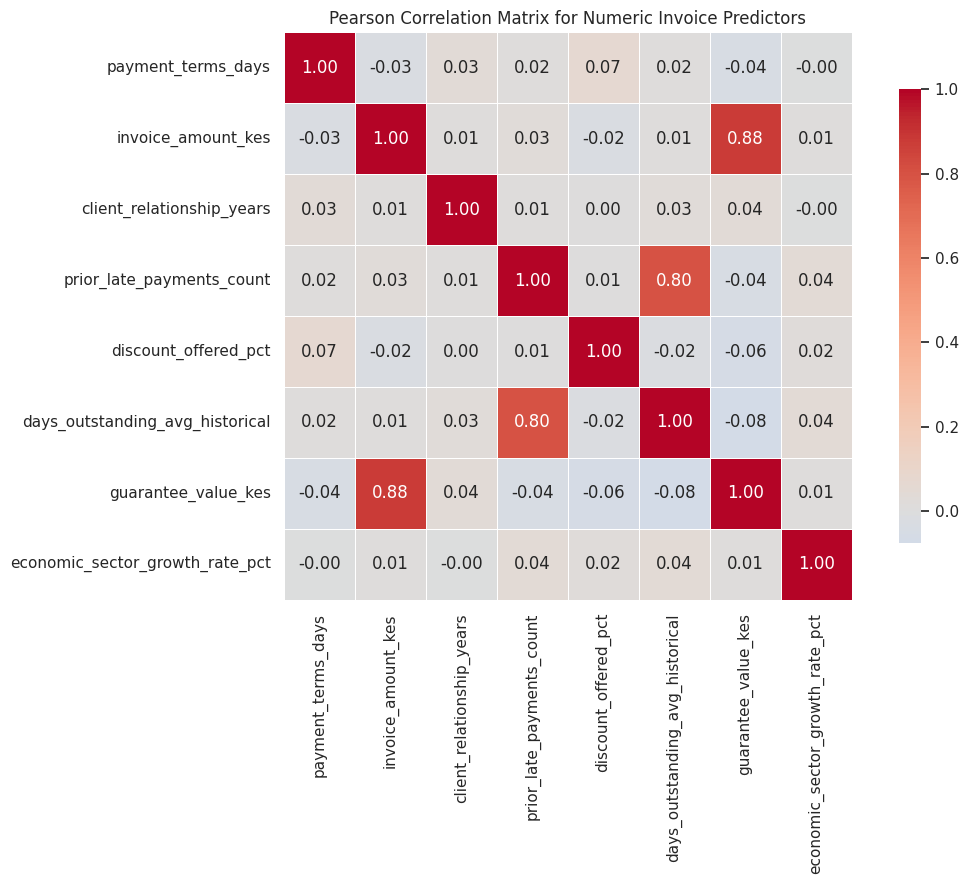

In [12]:
correlation_matrix = invoice_data[
    numeric_predictor_cols
].corr(method="pearson")

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Pearson Correlation Matrix for Numeric Invoice Predictors")

plt.tight_layout()
plt.show()

In [13]:
numeric_correlation = invoice_data[
    numeric_predictor_cols
].corr(method="pearson").abs()

high_correlation_pairs = []

for first_index in range(len(numeric_correlation.columns)):
    for second_index in range(
        first_index + 1,
        len(numeric_correlation.columns)
    ):
        correlation_value = numeric_correlation.iloc[
            first_index,
            second_index
        ]

        if correlation_value >= 0.80:
            high_correlation_pairs.append(
                {
                    "feature_1": numeric_correlation.columns[
                        first_index
                    ],
                    "feature_2": numeric_correlation.columns[
                        second_index
                    ],
                    "absolute_correlation": correlation_value,
                }
            )

high_correlation_pairs_df = pd.DataFrame(
    high_correlation_pairs
).sort_values(
    "absolute_correlation",
    ascending=False
)

display(high_correlation_pairs_df.round(4))

,feature_1,feature_2,absolute_correlation
0,invoice_amount_kes,guarantee_value_kes,0.8768
1,prior_late_payments_count,days_outstanding_avg_historical,0.8000


**Interpretation of Correlated Numeric Predictors**

The strongest correlation is between `invoice_amount_kes` and `guarantee_value_kes`, with an absolute Pearson correlation of 0.8768. This suggests that invoices with larger amounts tend to have larger guarantee values when a guarantee is recorded.

The correlation between `prior_late_payments_count` and `days_outstanding_avg_historical` is 0.8000. This is at the review threshold and is reasonable because both variables describe the client's historical payment behaviour.

These pairs may contain overlapping information. However, no variables are removed during exploratory data analysis. The relationships will be examined again during feature selection using the training data only.

`guarantee_value_kes` will be retained for now because its missing values are structurally related to invoices without collateral or a guarantee. The model may benefit from both the guarantee value and the information that no guarantee was recorded.

### Key Numeric Predictors by Payment Risk Category

Boxplots are used to compare the distributions of important numeric predictors across the `On-Time`, `Late`, and `Severely Late` payment-risk categories.

The selected variables had the strongest ANOVA results. These diagrams help show whether their values tend to differ across payment-risk categories.

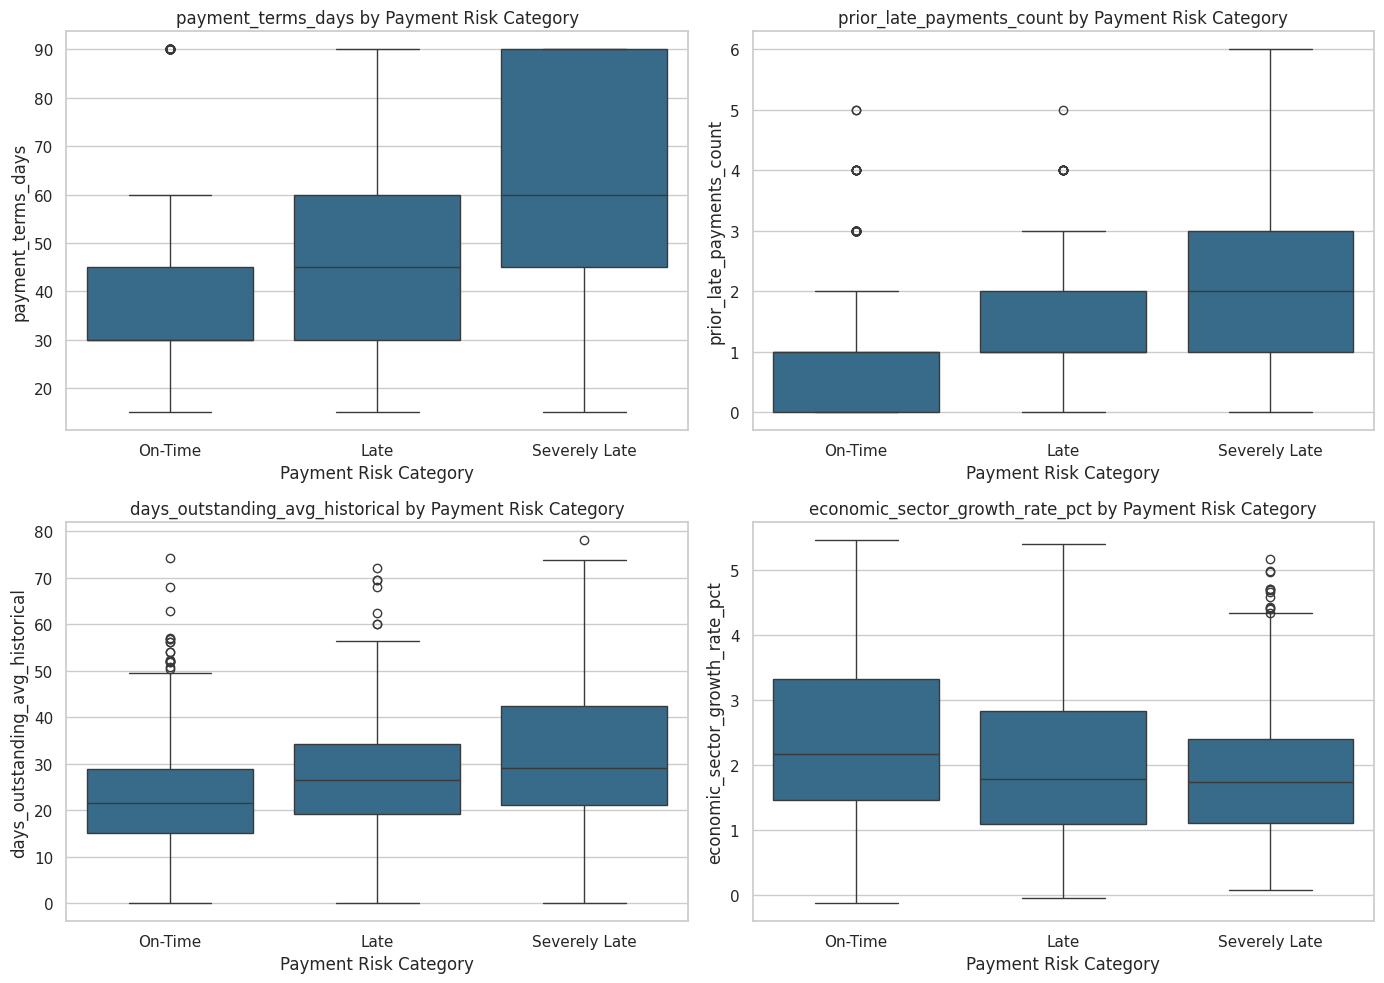

In [14]:
key_numeric_predictors = [
    "payment_terms_days",
    "prior_late_payments_count",
    "days_outstanding_avg_historical",
    "economic_sector_growth_rate_pct",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for axis, column in zip(
    axes.flatten(),
    key_numeric_predictors
):
    sns.boxplot(
        data=invoice_data,
        x=TARGET,
        y=column,
        order=CLASS_ORDER,
        ax=axis,
        color="#2A6F97"
    )

    axis.set_title(
        f"{column} by Payment Risk Category"
    )

    axis.set_xlabel("Payment Risk Category")
    axis.set_ylabel(column)

plt.tight_layout()
plt.show()

**Interpretation of Key Numeric Predictors by Payment Risk Category**

The boxplots show that `payment_terms_days` increases as payment risk increases. On-Time invoices have a median payment term of approximately 40 days, while Severely Late invoices have a higher median of approximately 60 days. This suggests that longer payment terms are associated with a higher payment risk category.

`prior_late_payments_count` also increases across the payment-risk categories. On-Time clients have a median of approximately zero prior late payments, Late clients have a median of approximately one, and Severely Late clients have a median of approximately two. Although some outliers appear across the categories, the overall pattern shows that a greater history of late payments is associated with higher payment risk.

`days_outstanding_avg_historical` follows a similar increasing pattern. On-Time invoices have a lower median number of historical days outstanding than Late and Severely Late invoices. This suggests that clients who have taken longer to settle invoices in the past are more likely to have a higher payment-risk category.

`economic_sector_growth_rate_pct` shows the opposite pattern. Its median value decreases slightly from On-Time to Severely Late invoices. The boxes overlap substantially, so this variable appears to be a weaker individual predictor than payment terms and previous payment behaviour. However, its ANOVA result was statistically significant, so it may still contribute useful information when combined with other variables.

Overall, `payment_terms_days`, `prior_late_payments_count`, and `days_outstanding_avg_historical` show the clearest relationships with payment risk. These variables will be examined further during the feature-selection and modeling stages. The observed relationships show association and do not prove causation.

## 4. Train/Test Split

The dataset is split into training data and test data before feature selection and preprocessing. This prevents information from the test data from influencing model development, which is known as data leakage.

An 80:20 split is used. Since `payment_risk_category` is imbalanced, the split is stratified using the target variable. This ensures that the `On-Time`, `Late`, and `Severely Late` categories are represented in similar proportions in both the training and test datasets.

The `invoice_id` column is excluded because it is an identifier and does not provide meaningful information for predicting payment risk.

In [15]:
from sklearn.model_selection import train_test_split

feature_cols = [
    column
    for column in invoice_data.columns
    if column not in ["invoice_id", TARGET]
]

X = invoice_data[feature_cols].copy()
y = invoice_data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(
    f"Training data: {X_train.shape[0]} rows "
    f"and {X_train.shape[1]} features"
)

print(
    f"Test data: {X_test.shape[0]} rows "
    f"and {X_test.shape[1]} features"
)

class_split_summary = pd.DataFrame(
    {
        "training_count": y_train.value_counts().reindex(
            CLASS_ORDER
        ),
        "training_percentage": (
            y_train.value_counts(normalize=True)
            .reindex(CLASS_ORDER)
            * 100
        ),
        "test_count": y_test.value_counts().reindex(
            CLASS_ORDER
        ),
        "test_percentage": (
            y_test.value_counts(normalize=True)
            .reindex(CLASS_ORDER)
            * 100
        ),
    }
)

display(class_split_summary.round(2))

Training data: 1200 rows and 14 features
Test data: 300 rows and 14 features


,training_count,training_percentage,test_count,test_percentage
payment_risk_category,,,,
On-Time,780,65.0,195,65.0
Late,300,25.0,75,25.0
Severely Late,120,10.0,30,10.0


**Interpretation of the Train/Test Split**

The dataset was split into 1,200 training invoices and 300 test invoices. Both datasets contain 14 predictor variables after removing the identifier column, `invoice_id`.

The split was stratified using `payment_risk_category`. As a result, both datasets preserve the same class proportions: 65% On-Time invoices, 25% Late invoices, and 10% Severely Late invoices.

The training data will be used for feature selection, preprocessing, resampling, model training, and hyperparameter tuning. The test data will remain untouched until the final model-evaluation stage.

## 5. Feature Selection

Feature selection is performed using the training data only. This helps identify predictors that may be useful for distinguishing between payment-risk categories while keeping the test dataset untouched for final evaluation.

The feature-selection methods in this section include the chi-square test for categorical predictors, ANOVA and mutual information for numeric predictors, and Recursive Feature Elimination with Cross-Validation (RFECV).

The results from these methods will be considered together before making any final decision about which variables to retain.

### Chi-Square Test for Categorical Predictors

The chi-square test is used to examine the relationship between each categorical predictor and the payment-risk category.

A higher chi-square statistic suggests that the distribution of a categorical variable differs more across the `On-Time`, `Late`, and `Severely Late` classes. A p-value below 0.05 suggests that the relationship is statistically significant.

This test is used as an initial screening method. The final feature-selection decision will consider multiple methods and the business meaning of each variable.

In [16]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

print(
    f"Starting feature count: "
    f"{X_train.shape[1]}"
)

categorical_train = X_train[
    categorical_predictor_cols
].copy()

categorical_train_encoded = pd.DataFrame(
    index=categorical_train.index
)

for column in categorical_predictor_cols:
    encoder = LabelEncoder()

    categorical_train_encoded[column] = (
        encoder.fit_transform(
            categorical_train[column].astype(str)
        )
    )

chi2_statistics, chi2_p_values = chi2(
    categorical_train_encoded,
    y_train
)

chi2_summary = pd.DataFrame(
    {
        "feature": categorical_predictor_cols,
        "chi2_statistic": chi2_statistics,
        "p_value": chi2_p_values,
    }
).sort_values(
    "chi2_statistic",
    ascending=False
)

display(chi2_summary.round(4))

Starting feature count: 14


,feature,chi2_statistic,p_value
1,client_credit_rating,42.3348,0.0000
4,has_dispute_history,37.2020,0.0000
0,client_industry,7.5515,0.0229
3,payment_method,3.7542,0.1530
5,collateral_or_guarantee,1.9031,0.3862
2,client_company_size,0.6745,0.7137


**Interpretation of Categorical Feature Selection**

`client_credit_rating` has the strongest relationship with payment risk, with a chi-square statistic of 42.3348. `has_dispute_history` also has a strong relationship, with a chi-square statistic of 37.2020. Both p-values are displayed as 0.0000 after rounding, which indicates strong statistical evidence of an association with payment-risk category.

`client_industry` has a smaller but statistically significant relationship with payment risk, with a chi-square statistic of 7.5515 and a p-value of 0.0229.

`payment_method`, `collateral_or_guarantee`, and `client_company_size` do not have statistically significant individual relationships with payment risk in this chi-square test. However, they will not be removed at this stage.

`collateral_or_guarantee` is retained because it is related to the structural missingness of `guarantee_value_kes`. A variable with a weak individual relationship may still contribute useful information when combined with other predictors in a classification model.

### ANOVA F-Test and Mutual Information for Numeric Predictors

The ANOVA F-test and mutual information are used to assess numeric predictors using the training data only.

The ANOVA F-test identifies variables whose average values differ across the payment-risk categories. A high F-statistic and a low p-value suggest stronger separation between the classes.

Mutual information measures how much information a numeric predictor provides about payment risk. Unlike ANOVA, it can identify non-linear relationships as well as linear relationships.

Missing values in `guarantee_value_kes` are temporarily replaced with the training median only for this diagnostic calculation. The final preprocessing pipeline will handle its structural missingness separately.

In [17]:
from sklearn.feature_selection import (
    f_classif,
    mutual_info_classif,
)

numeric_train = X_train[
    numeric_predictor_cols
].copy()

numeric_train_filled = numeric_train.fillna(
    numeric_train.median()
)

anova_f_statistics, anova_p_values = f_classif(
    numeric_train_filled,
    y_train
)

mutual_information_scores = mutual_info_classif(
    numeric_train_filled,
    y_train,
    random_state=RANDOM_STATE
)

numeric_selection_summary = pd.DataFrame(
    {
        "feature": numeric_predictor_cols,
        "ANOVA_F_statistic": anova_f_statistics,
        "ANOVA_p_value": anova_p_values,
        "mutual_information": mutual_information_scores,
    }
).sort_values(
    "mutual_information",
    ascending=False
)

display(numeric_selection_summary.round(4))

,feature,ANOVA_F_statistic,ANOVA_p_value,mutual_information
0,payment_terms_days,130.6676,0.0000,0.1016
3,prior_late_payments_count,46.2212,0.0000,0.0762
1,invoice_amount_kes,0.4884,0.6137,0.0132
4,discount_offered_pct,2.2857,0.1021,0.0065
5,days_outstanding_avg_historical,37.6530,0.0000,0.0032
2,client_relationship_years,0.4454,0.6407,0.0000
6,guarantee_value_kes,0.9681,0.3801,0.0000
7,economic_sector_growth_rate_pct,10.5455,0.0000,0.0000


**Interpretation of Numeric Feature Selection**

`payment_terms_days` has the strongest numeric relationship with payment risk. It has an ANOVA F-statistic of 130.6676 and the highest mutual-information score of 0.1016.

`prior_late_payments_count` is the second strongest numeric predictor, with an ANOVA F-statistic of 46.2212 and a mutual-information score of 0.0762. These findings support the earlier boxplots, which showed that clients with a greater history of late payments tend to have higher payment-risk categories.

`days_outstanding_avg_historical` also has a strong ANOVA F-statistic of 37.6530. This suggests that historical payment delays differ across the payment-risk categories.

`economic_sector_growth_rate_pct` has a statistically significant ANOVA result, although its mutual-information score is close to zero. This suggests that it may provide limited information on its own.

The remaining numeric variables have weaker individual results. However, they will not be removed at this stage. In particular, `guarantee_value_kes` is retained because its structural missingness may provide useful information when combined with other predictors.

RFECV will now be used to identify the numeric features that contribute most to classification performance.

### Recursive Feature Elimination With Cross-Validation

Recursive Feature Elimination with Cross-Validation (RFECV) repeatedly fits a classification model and removes weaker numeric predictors until it identifies a suitable feature set.

RFECV uses stratified cross-validation so that each fold preserves the proportions of `On-Time`, `Late`, and `Severely Late` invoices. Macro F1-score is used because it gives equal importance to all payment-risk categories, including the minority `Severely Late` category.

In [18]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

numeric_feature_names = (
    numeric_train_filled.columns.tolist()
)

scaler_for_rfecv = StandardScaler()

numeric_train_scaled = (
    scaler_for_rfecv.fit_transform(
        numeric_train_filled
    )
)

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rfecv_selector = RFECV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    step=1,
    cv=stratified_kfold,
    scoring="f1_macro",
    min_features_to_select=1
)

rfecv_selector.fit(
    numeric_train_scaled,
    y_train
)

rfecv_ranking = pd.DataFrame(
    {
        "feature": numeric_feature_names,
        "selected": rfecv_selector.support_,
        "rank": rfecv_selector.ranking_,
    }
).sort_values(
    ["selected", "rank"],
    ascending=[False, True]
)

print(
    f"Optimal number of numeric features: "
    f"{rfecv_selector.n_features_}"
)

display(rfecv_ranking)

Optimal number of numeric features: 8


,feature,selected,rank
0,payment_terms_days,True,1
1,invoice_amount_kes,True,1
2,client_relationship_years,True,1
3,prior_late_payments_count,True,1
4,discount_offered_pct,True,1
5,days_outstanding_avg_historical,True,1
6,guarantee_value_kes,True,1
7,economic_sector_growth_rate_pct,True,1


### RFECV Feature Selection Decision

RFECV selected all eight numeric predictor variables. This means that removing any numeric variable reduced the macro F1-score during stratified cross-validation.

Therefore, all numeric variables are retained: `payment_terms_days`, `invoice_amount_kes`, `client_relationship_years`, `prior_late_payments_count`, `discount_offered_pct`, `days_outstanding_avg_historical`, `guarantee_value_kes`, and `economic_sector_growth_rate_pct`.

The six categorical variables are also retained. Although some categorical variables had weaker individual chi-square results, they may still contribute useful information when combined with other invoice and client characteristics.

The final feature-selection decision is to retain all 14 predictor variables and exclude only `invoice_id`, which is an identifier. This decision was made using training data only.

In [19]:
selected_numeric_features = [
    feature
    for feature, selected in zip(
        numeric_feature_names,
        rfecv_selector.support_
    )
    if selected
]

selected_categorical_features = (
    categorical_predictor_cols.copy()
)

selected_features = (
    selected_numeric_features
    + selected_categorical_features
)

X_train_selected = X_train[
    selected_features
].copy()

X_test_selected = X_test[
    selected_features
].copy()

print("Selected numeric features:")
print(selected_numeric_features)

print("\nSelected categorical features:")
print(selected_categorical_features)

print(
    f"\nTraining data after feature selection: "
    f"{X_train_selected.shape[0]} rows and "
    f"{X_train_selected.shape[1]} features"
)

print(
    f"Test data after feature selection: "
    f"{X_test_selected.shape[0]} rows and "
    f"{X_test_selected.shape[1]} features"
)

Selected numeric features:
['payment_terms_days', 'invoice_amount_kes', 'client_relationship_years', 'prior_late_payments_count', 'discount_offered_pct', 'days_outstanding_avg_historical', 'guarantee_value_kes', 'economic_sector_growth_rate_pct']

Selected categorical features:
['client_industry', 'client_credit_rating', 'client_company_size', 'payment_method', 'has_dispute_history', 'collateral_or_guarantee']

Training data after feature selection: 1200 rows and 14 features
Test data after feature selection: 300 rows and 14 features


## 6. Preprocessing and Resampling

Preprocessing is performed after feature selection and uses the training data only. The preprocessing pipeline will handle missing values, categorical encoding, and differences in scale between numeric variables.

The target variable is imbalanced, with `Severely Late` invoices representing only 10% of the data. Resampling will be applied later inside the classification pipeline using training data only. The test dataset will not be resampled because it should retain the real payment-risk distribution.

**Categorical Encoding Plan**

The categorical variables are examined to determine whether they should be encoded as nominal or ordinal variables.

`client_credit_rating` has an expected natural order, from lower to higher credit quality. The other categorical variables describe categories without a natural numeric order and will later be one-hot encoded.

In [20]:
for column in selected_categorical_features:
    print(f"\n{column}:")
    print(
        sorted(
            X_train_selected[column]
            .dropna()
            .unique()
        )
    )


client_industry:
['Construction', 'Healthcare', 'Manufacturing', 'Retail', 'Technology']

client_credit_rating:
['Excellent', 'Fair', 'Good', 'Poor']

client_company_size:
['Enterprise', 'Large', 'Medium', 'Small']

payment_method:
['Bank Transfer', 'Cheque', 'Letter of Credit', 'Mobile Money']

has_dispute_history:
['No', 'Yes']

collateral_or_guarantee:
['No', 'Yes']


### Preprocessing Decisions

`client_credit_rating` and `client_company_size` have a natural order. They will be ordinal encoded so that their categories retain this order.

`client_industry`, `payment_method`, `has_dispute_history`, and `collateral_or_guarantee` do not have a numeric order. They will be one-hot encoded.

`guarantee_value_kes` has structural missingness because a guarantee value is missing whenever `collateral_or_guarantee` is recorded as `No`. It will be median imputed with a missingness indicator so that the model can use both the recorded guarantee value and the fact that no guarantee was recorded.

The numeric variables will be standardized using `StandardScaler`. The preprocessing pipeline is constructed here but will be fitted later inside each classification pipeline using training data only.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

guarantee_feature = [
    "guarantee_value_kes"
]

other_numeric_features = [
    feature
    for feature in selected_numeric_features
    if feature not in guarantee_feature
]

ordinal_features = [
    "client_credit_rating",
    "client_company_size",
]

nominal_features = [
    feature
    for feature in selected_categorical_features
    if feature not in ordinal_features
]

credit_rating_order = [
    "Poor",
    "Fair",
    "Good",
    "Excellent",
]

company_size_order = [
    "Small",
    "Medium",
    "Large",
    "Enterprise",
]

guarantee_pipeline = SkPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            ),
        ),
        ("scaler", StandardScaler()),
    ]
)

numeric_pipeline = SkPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        ("scaler", StandardScaler()),
    ]
)

nominal_pipeline = SkPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
        ),
    ]
)

ordinal_pipeline = SkPipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    credit_rating_order,
                    company_size_order,
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "guarantee",
            guarantee_pipeline,
            guarantee_feature
        ),
        (
            "numeric",
            numeric_pipeline,
            other_numeric_features
        ),
        (
            "nominal",
            nominal_pipeline,
            nominal_features
        ),
        (
            "ordinal",
            ordinal_pipeline,
            ordinal_features
        ),
    ]
)

print("Guarantee value feature:")
print(guarantee_feature)

print("\nOther numeric features:")
print(other_numeric_features)

print("\nNominal categorical features:")
print(nominal_features)

print("\nOrdinal categorical features:")
print(ordinal_features)

print("\nPreprocessing pipeline constructed successfully.")

Guarantee value feature:
['guarantee_value_kes']

Other numeric features:
['payment_terms_days', 'invoice_amount_kes', 'client_relationship_years', 'prior_late_payments_count', 'discount_offered_pct', 'days_outstanding_avg_historical', 'economic_sector_growth_rate_pct']

Nominal categorical features:
['client_industry', 'payment_method', 'has_dispute_history', 'collateral_or_guarantee']

Ordinal categorical features:
['client_credit_rating', 'client_company_size']

Preprocessing pipeline constructed successfully.


### Resampling Strategy Comparison

The training data is imbalanced because `Severely Late` invoices make up only 10% of the payment-risk categories. Resampling methods are considered to help classification models learn from the minority class.

SMOTE creates synthetic examples of minority classes, while ADASYN creates more synthetic examples in harder-to-learn areas. Random undersampling reduces the number of observations in the majority class.

These methods are examined using the training data only. The test data remains unchanged because it must represent the real payment-risk distribution. Class weighting will also be considered later for models that support it, but it does not change the number of training observations.

In [22]:
from sklearn.base import clone
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# This transformed copy is used only to preview class counts
# after each resampling method. It is not the final model pipeline.
preview_preprocessor = clone(preprocessor)

X_train_preview = preview_preprocessor.fit_transform(
    X_train_selected
)

resamplers = {
    "Original (No Resampling)": None,
    "SMOTE": SMOTE(
        random_state=RANDOM_STATE
    ),
    "ADASYN": ADASYN(
        random_state=RANDOM_STATE
    ),
    "Random Undersampling": RandomUnderSampler(
        random_state=RANDOM_STATE
    ),
}

resampling_counts = {}

for method_name, resampler in resamplers.items():
    if resampler is None:
        y_resampled = y_train
    else:
        _, y_resampled = resampler.fit_resample(
            X_train_preview,
            y_train
        )

    resampling_counts[method_name] = (
        pd.Series(y_resampled)
        .value_counts()
        .reindex(CLASS_ORDER)
    )

resampling_summary = pd.DataFrame(
    resampling_counts
)

display(resampling_summary)

print(
    "Class weighting is not shown in this table because it "
    "does not change class counts."
)

,Original (No Resampling),SMOTE,ADASYN,Random Undersampling
payment_risk_category,,,,
On-Time,780,780,780,120
Late,300,780,736,120
Severely Late,120,780,760,120


Class weighting is not shown in this table because it does not change class counts.


**Interpretation of Resampling Strategies**

The original training data is imbalanced, with 780 On-Time invoices, 300 Late invoices, and 120 Severely Late invoices.

SMOTE balances the three payment-risk classes by creating synthetic examples for the Late and Severely Late categories. After SMOTE, each class has 780 observations.

ADASYN also creates synthetic minority-class examples, resulting in 736 Late invoices and 760 Severely Late invoices. Unlike SMOTE, ADASYN focuses more on observations that are harder to classify, so its class counts are not exactly equal.

Random undersampling reduces all classes to 120 observations. Although this creates a balanced dataset, it removes many On-Time invoices and may discard useful information.

SMOTE will be used in the initial classification pipelines because it balances the classes without removing original training observations. The resampling step will remain inside the pipeline so that it is applied only to training data.

## 7. Modeling and Cross-Validation

Several classification models are compared using the same preprocessing and SMOTE-resampling pipeline.

Stratified 5-fold cross-validation is used so that every fold maintains similar proportions of On-Time, Late, and Severely Late invoices. Macro F1-score is used as the main evaluation metric because it gives equal importance to all three payment-risk categories.

A high accuracy score alone may be misleading because On-Time invoices are the majority class. Macro F1-score provides a more balanced assessment of model performance across all payment-risk categories.

In [23]:
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=15
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        n_jobs=1,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=RANDOM_STATE
    ),
    "Support Vector Machine": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": GaussianNB(),
}

stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Models to compare:")
print(list(models.keys()))

print("\nCross-validation method: Stratified 5-Fold")

print("\nMain metric: Macro F1-score")

Models to compare:
['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'Support Vector Machine', 'Naive Bayes']

Cross-validation method: Stratified 5-Fold

Main metric: Macro F1-score


In [24]:
cv_scores = {}
cv_summary_rows = {}

for model_name, model in models.items():
    pipeline = ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "smote",
                SMOTE(random_state=RANDOM_STATE)
            ),
            ("model", model),
        ]
    )

    scores = cross_val_score(
        pipeline,
        X_train_selected,
        y_train,
        cv=stratified_kfold,
        scoring="f1_macro",
        n_jobs=-1
    )

    cv_scores[model_name] = scores

    cv_summary_rows[model_name] = {
        "mean_cv_f1_macro": scores.mean(),
        "std_cv_f1_macro": scores.std(),
    }

cv_summary = (
    pd.DataFrame
    .from_dict(
        cv_summary_rows,
        orient="index"
    )
    .reset_index(names="model")
    .sort_values(
        "mean_cv_f1_macro",
        ascending=False
    )
    .reset_index(drop=True)
)

display(cv_summary.round(4))

,model,mean_cv_f1_macro,std_cv_f1_macro
0,Logistic Regression,0.6276,0.0418
1,Random Forest,0.5839,0.0353
2,Gradient Boosting,0.5766,0.0386
3,Support Vector Machine,0.5690,0.0373
4,Naive Bayes,0.5333,0.0324
5,Decision Tree,0.5173,0.0400
6,K-Nearest Neighbors,0.4963,0.0264


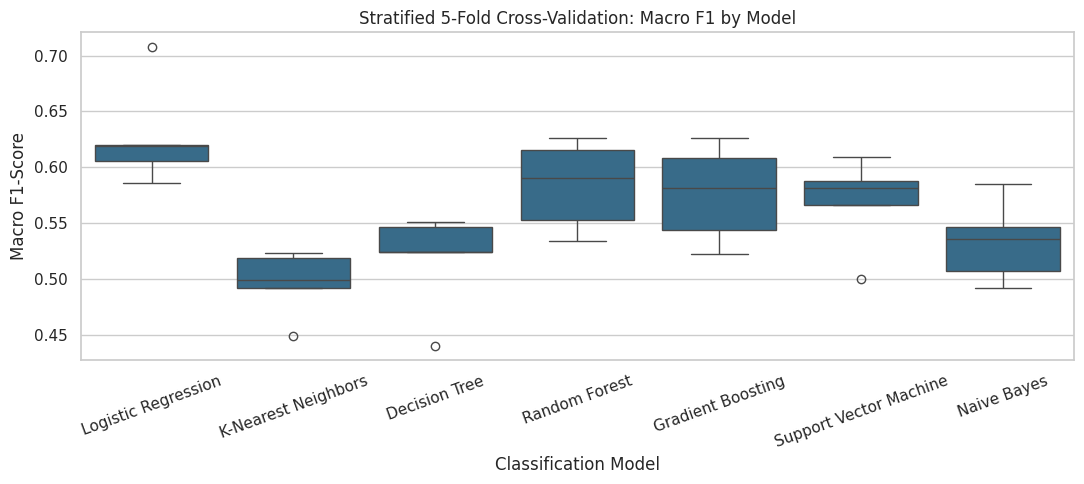

In [25]:
cv_scores_df = pd.DataFrame(cv_scores)

plt.figure(figsize=(11, 5))

sns.boxplot(
    data=cv_scores_df,
    color="#2A6F97"
)

plt.title(
    "Stratified 5-Fold Cross-Validation: Macro F1 by Model"
)

plt.xlabel("Classification Model")
plt.ylabel("Macro F1-Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Interpretation of Cross-Validation Results**

Logistic Regression achieved the highest mean macro F1-score of 0.6276 during stratified 5-fold cross-validation. This means that it had the strongest balanced performance across the On-Time, Late, and Severely Late payment-risk categories.

Random Forest and Gradient Boosting had lower mean macro F1-scores of 0.5839 and 0.5766 respectively. Support Vector Machine also performed below Logistic Regression, with a mean macro F1-score of 0.5690.

K-Nearest Neighbors had the lowest macro F1-score of 0.4963. This suggests that it was less effective at distinguishing between the three payment-risk categories.

Logistic Regression is the leading candidate based on cross-validation. However, all models will still be evaluated using the untouched test dataset before the final model is selected.

## 8. Classification Diagnostics

Classification diagnostics are used to examine how well the model distinguishes between the three payment-risk categories.

The diagnostics include a confusion matrix, ROC curves, precision-recall curves, and a classification report. These checks are important because overall accuracy alone can be misleading when the payment-risk categories are imbalanced.

The Severely Late category is the minority class and is especially important because these invoices may require earlier payment follow-up or closer credit review.

### Logistic Regression Diagnostic Pipeline

A Logistic Regression pipeline is fitted using the training data. The pipeline includes preprocessing, SMOTE resampling, and the classification model.

SMOTE is applied only when the pipeline is fitted on training data. It does not resample the held-out test dataset when predictions are made.

In [26]:
logistic_diagnostic_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "smote",
            SMOTE(random_state=RANDOM_STATE)
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                random_state=RANDOM_STATE
            ),
        ),
    ]
)

logistic_diagnostic_pipeline.fit(
    X_train_selected,
    y_train
)

diagnostic_class_order = list(
    logistic_diagnostic_pipeline
    .named_steps["model"]
    .classes_
)

y_pred_logistic = logistic_diagnostic_pipeline.predict(
    X_test_selected
)

y_proba_logistic = logistic_diagnostic_pipeline.predict_proba(
    X_test_selected
)

print("Class order used by the diagnostic model:")
print(diagnostic_class_order)

print(
    f"Test invoices predicted: "
    f"{len(y_pred_logistic)}"
)

Class order used by the diagnostic model:
['Late', 'On-Time', 'Severely Late']
Test invoices predicted: 300


### Confusion Matrix

A confusion matrix compares the actual payment-risk category with the category predicted by the model.

The diagonal values show correct predictions. Values outside the diagonal show where the model confuses one payment-risk category with another. The Severely Late row is especially important because it shows how many genuinely high-risk invoices the model identifies correctly.

,Predicted: Late,Predicted: On-Time,Predicted: Severely Late
Actual: Late,44,12,19
Actual: On-Time,39,151,5
Actual: Severely Late,6,0,24


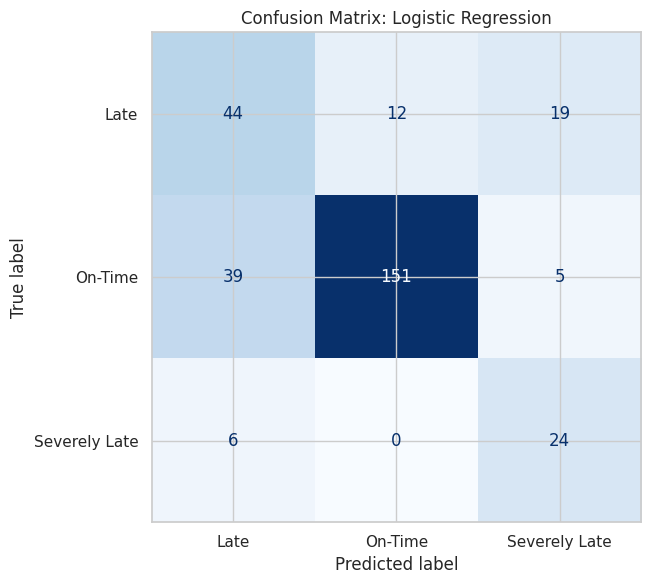

In [27]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
)

logistic_confusion_matrix = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=diagnostic_class_order
)

display(
    pd.DataFrame(
        logistic_confusion_matrix,
        index=[
            f"Actual: {label}"
            for label in diagnostic_class_order
        ],
        columns=[
            f"Predicted: {label}"
            for label in diagnostic_class_order
        ],
    )
)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=diagnostic_class_order
)

fig, axis = plt.subplots(figsize=(7, 6))

confusion_display.plot(
    ax=axis,
    cmap="Blues",
    colorbar=False
)

axis.set_title(
    "Confusion Matrix: Logistic Regression"
)

plt.tight_layout()
plt.show()

**Interpretation of the Confusion Matrix**

The Logistic Regression model correctly classified 151 of 195 On-Time invoices, 44 of 75 Late invoices, and 24 of 30 Severely Late invoices.

The model identified 80% of the Severely Late invoices correctly. Importantly, none of the Severely Late invoices were predicted as On-Time. However, 6 Severely Late invoices were predicted as Late.

The model had more difficulty distinguishing the Late category. Nineteen actual Late invoices were predicted as Severely Late, while 12 actual Late invoices were predicted as On-Time.

Most On-Time invoices were classified correctly. However, 39 On-Time invoices were predicted as Late. This means that the model may flag some On-Time invoices for additional review.

Overall, the confusion matrix shows that the model can identify many Severely Late invoices, but it sometimes confuses the Late and Severely Late categories. This is important because the three classes represent different levels of payment risk.

### ROC Curves

The Receiver Operating Characteristic (ROC) curve is used to examine how well the Logistic Regression model distinguishes each payment-risk category from the other categories.

The ROC curve is calculated separately for On-Time, Late, and Severely Late invoices using a one-versus-rest approach. The Area Under the Curve (AUC) summarizes the model's ability to separate each class from the other classes.

An AUC value close to 1 indicates strong class separation, while a value close to 0.5 indicates performance close to random guessing.

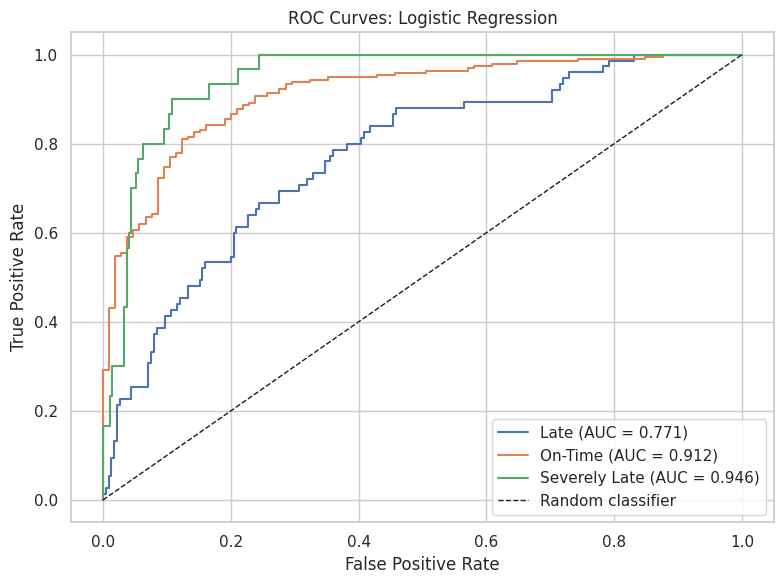

In [28]:
from sklearn.metrics import (
    auc,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

y_test_binarized = label_binarize(
    y_test,
    classes=diagnostic_class_order
)

fig, axis = plt.subplots(figsize=(8, 6))

for class_index, class_name in enumerate(
    diagnostic_class_order
):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_test_binarized[:, class_index],
        y_proba_logistic[:, class_index]
    )

    roc_auc = auc(
        false_positive_rate,
        true_positive_rate
    )

    axis.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{class_name} (AUC = {roc_auc:.3f})"
    )

axis.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=1,
    label="Random classifier"
)

axis.set_xlabel("False Positive Rate")
axis.set_ylabel("True Positive Rate")
axis.set_title(
    "ROC Curves: Logistic Regression"
)

axis.legend()
plt.tight_layout()
plt.show()

**Interpretation of ROC Curves**

The Logistic Regression model shows strong ability to distinguish the On-Time and Severely Late payment-risk categories from the other categories.

The Severely Late category has the highest AUC value of 0.946. This shows that the model is very effective at distinguishing Severely Late invoices from On-Time and Late invoices. This is useful because Severely Late invoices may require earlier collection action or closer credit review.

The On-Time category has an AUC value of 0.912, which also indicates strong classification performance. The model can distinguish most On-Time invoices from invoices with a higher payment risk.

The Late category has the lowest AUC value of 0.771. This is still better than random classification, but it shows that the model has more difficulty separating Late invoices from the other two categories.

A likely reason is that Late invoices represent the middle payment-risk category. Their characteristics may overlap with both On-Time and Severely Late invoices. The ROC results show that the model separates the extreme categories more clearly than the middle category.

Although the Severely Late ROC result is strong, it is still important to examine the precision-recall curve because Severely Late is the minority class in the test dataset.

### Precision-Recall Curves

Precision-recall curves are used to examine how well the Logistic Regression model identifies each payment-risk category.

Precision shows how many invoices predicted in a category were actually in that category. Recall shows how many of the actual invoices in a category were correctly identified by the model.

Precision-recall curves are especially important for the Severely Late category because it is the minority class. ROC-AUC can appear strong in imbalanced data, while precision-recall analysis gives a clearer view of whether invoices flagged as Severely Late are likely to be truly Severely Late.

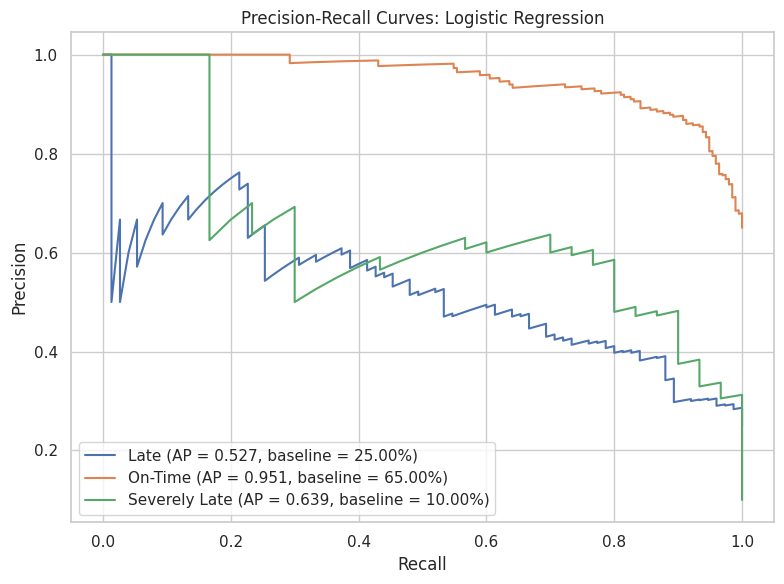

,class,average_precision,class_baseline
1,On-Time,0.9510,0.65
2,Severely Late,0.6392,0.10
0,Late,0.5271,0.25


In [29]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
)

precision_recall_results = []

fig, axis = plt.subplots(figsize=(8, 6))

for class_index, class_name in enumerate(
    diagnostic_class_order
):
    precision, recall, _ = precision_recall_curve(
        y_test_binarized[:, class_index],
        y_proba_logistic[:, class_index]
    )

    average_precision = average_precision_score(
        y_test_binarized[:, class_index],
        y_proba_logistic[:, class_index]
    )

    class_baseline = (
        y_test_binarized[:, class_index].mean()
    )

    precision_recall_results.append(
        {
            "class": class_name,
            "average_precision": average_precision,
            "class_baseline": class_baseline,
        }
    )

    axis.plot(
        recall,
        precision,
        label=(
            f"{class_name} "
            f"(AP = {average_precision:.3f}, "
            f"baseline = {class_baseline:.2%})"
        )
    )

axis.set_xlabel("Recall")
axis.set_ylabel("Precision")

axis.set_title(
    "Precision-Recall Curves: Logistic Regression"
)

axis.legend()

plt.tight_layout()
plt.show()

precision_recall_summary = pd.DataFrame(
    precision_recall_results
).sort_values(
    "average_precision",
    ascending=False
)

display(precision_recall_summary.round(4))

**Interpretation of Precision-Recall Curves**

The On-Time category has the highest average precision score of 0.9510. Its baseline rate is 0.65 because 65% of the test invoices are On-Time. The model performs substantially better than this baseline when identifying On-Time invoices.

The Severely Late category has an average precision score of 0.6392, compared with a baseline rate of 0.10. This shows that the model provides useful information for identifying Severely Late invoices beyond what would be expected from randomly selecting invoices.

The Late category has the lowest average precision score of 0.5271. However, this is still above its baseline rate of 0.25, meaning that the model is still useful for identifying Late invoices even though this category is more difficult to distinguish.

The precision-recall results support the earlier ROC findings. The model performs best for On-Time invoices, performs strongly for Severely Late invoices, and has more difficulty with the Late category.

The Severely Late result should be interpreted carefully because there are only 30 Severely Late invoices in the test dataset. However, the model appears useful as an early-warning tool for identifying invoices that may require closer payment follow-up.

### Classification Report

The classification report shows precision, recall, and F1-score for each payment-risk category.

Precision shows how many invoices predicted in a category were actually in that category. Recall shows how many actual invoices in a category were correctly identified. The F1-score balances precision and recall.

Macro averages give equal importance to On-Time, Late, and Severely Late invoices. Weighted averages give more influence to the majority On-Time category. Since Severely Late is the minority category, macro F1-score is more useful for assessing balanced model performance.

In [30]:
from sklearn.metrics import classification_report

logistic_report = classification_report(
    y_test,
    y_pred_logistic,
    labels=diagnostic_class_order,
    output_dict=True,
    zero_division=0
)

logistic_report_df = (
    pd.DataFrame(logistic_report)
    .T
    .loc[
        diagnostic_class_order
        + ["macro avg", "weighted avg"],
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
)

print(
    f"Logistic Regression accuracy: "
    f"{logistic_report['accuracy']:.4f}"
)

display(logistic_report_df.round(4))

Logistic Regression accuracy: 0.7300


,precision,recall,f1-score,support
Late,0.4944,0.5867,0.5366,75.0
On-Time,0.9264,0.7744,0.8436,195.0
Severely Late,0.5000,0.8000,0.6154,30.0
macro avg,0.6403,0.7203,0.6652,300.0
weighted avg,0.7757,0.7300,0.7440,300.0


**Interpretation of the Classification Report**

The Logistic Regression model achieved an accuracy of 0.7300 on the held-out test dataset. However, accuracy alone is not enough because On-Time invoices are the majority class.

The macro F1-score is 0.6652, while the weighted F1-score is 0.7440. The weighted score is higher because it gives more influence to the larger On-Time category. The macro F1-score is more useful because it gives equal importance to On-Time, Late, and Severely Late invoices.

The model performs best for On-Time invoices, with an F1-score of 0.8436. It correctly identifies many On-Time invoices, although some are incorrectly flagged as Late.

For Severely Late invoices, the model has a recall of 0.8000 and an F1-score of 0.6154. This means it correctly identifies 24 out of 30 Severely Late invoices. However, its precision is 0.5000, meaning that only half of the invoices predicted as Severely Late are actually Severely Late.

The Late category has the lowest F1-score of 0.5366. This supports the ROC and precision-recall results, which showed that Late invoices are more difficult to distinguish from the other two payment-risk categories.

Overall, the Logistic Regression model is useful for identifying Severely Late invoices, but the results show that performance differs across the three payment-risk categories.

## 9. Held-Out Test-Set Evaluation

All classification models are fitted using the training data and evaluated once using the held-out test dataset.

Each model uses the same preprocessing pipeline and SMOTE resampling method. SMOTE is applied only when fitting the training data. The test dataset remains in its original imbalanced form so that it provides an honest measure of model performance.

Models will be compared using accuracy, macro and weighted precision, recall, F1-score, ROC-AUC, precision-recall AUC, and log loss. Macro F1-score will be the main model-selection metric because it gives equal importance to all payment-risk categories.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

evaluation_results = []
fitted_model_pipelines = {}

for model_name, model in models.items():
    pipeline = ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "smote",
                SMOTE(random_state=RANDOM_STATE)
            ),
            ("model", model),
        ]
    )

    pipeline.fit(
        X_train_selected,
        y_train
    )

    y_pred = pipeline.predict(
        X_test_selected
    )

    y_proba = pipeline.predict_proba(
        X_test_selected
    )

    model_classes = pipeline.named_steps[
        "model"
    ].classes_

    y_test_binarized_for_model = label_binarize(
        y_test,
        classes=model_classes
    )

    evaluation_results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(
                y_test,
                y_pred
            ),
            "Precision (macro)": precision_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),
            "Precision (weighted)": precision_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            "Recall (macro)": recall_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),
            "Recall (weighted)": recall_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            "F1 (macro)": f1_score(
                y_test,
                y_pred,
                average="macro",
                zero_division=0
            ),
            "F1 (weighted)": f1_score(
                y_test,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            "ROC-AUC (macro)": roc_auc_score(
                y_test,
                y_proba,
                multi_class="ovr",
                average="macro",
                labels=model_classes
            ),
            "PR-AUC (macro)": average_precision_score(
                y_test_binarized_for_model,
                y_proba,
                average="macro"
            ),
            "Log Loss": log_loss(
                y_test,
                y_proba,
                labels=model_classes
            ),
        }
    )

    fitted_model_pipelines[model_name] = pipeline

evaluation_df = (
    pd.DataFrame(evaluation_results)
    .sort_values(
        "F1 (macro)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(evaluation_df.round(4))

best_untuned_model_name = evaluation_df.loc[
    0,
    "Model"
]

best_untuned_pipeline = fitted_model_pipelines[
    best_untuned_model_name
]

print(
    f"Best untuned model by macro F1-score: "
    f"{best_untuned_model_name}"
)

,Model,Accuracy,Precision (macro),Precision (weighted),Recall (macro),Recall (weighted),F1 (macro),F1 (weighted),ROC-AUC (macro),PR-AUC (macro),Log Loss
0,Logistic Regression,0.7300,0.6403,0.7757,0.7203,0.7300,0.6652,0.7440,0.8767,0.7058,0.6145
1,Decision Tree,0.7300,0.6260,0.7481,0.6491,0.7300,0.6358,0.7376,0.8291,0.5904,1.3240
2,Random Forest,0.7500,0.6260,0.7450,0.6135,0.7500,0.6193,0.7473,0.8612,0.6402,0.6490
3,Support Vector Machine,0.7100,0.5931,0.7345,0.6239,0.7100,0.6052,0.7200,0.8507,0.6250,0.6610
4,Gradient Boosting,0.7333,0.6058,0.7251,0.6074,0.7333,0.6051,0.7281,0.8609,0.6551,0.5904
5,Naive Bayes,0.6500,0.5632,0.7258,0.6308,0.6500,0.5766,0.6732,0.8171,0.6034,0.7929
6,K-Nearest Neighbors,0.6433,0.5461,0.7078,0.6043,0.6433,0.5594,0.6651,0.7767,0.5411,2.1352


Best untuned model by macro F1-score: Logistic Regression


**Interpretation of Held-Out Test-Set Evaluation**

Logistic Regression achieved the highest macro F1-score of 0.6652 on the held-out test dataset. It also achieved the highest macro precision of 0.6403, macro recall of 0.7203, macro ROC-AUC of 0.8767, and macro PR-AUC of 0.7058.

Although Random Forest achieved the highest accuracy of 0.7500, its macro F1-score of 0.6193 was lower than the Logistic Regression score. This shows why accuracy alone is not sufficient for selecting a model when the payment-risk categories are imbalanced.

Logistic Regression is selected as the best untuned model because macro F1-score is the main selection metric. Macro F1 gives equal importance to On-Time, Late, and Severely Late invoices, including the minority Severely Late category.

The model will now be tuned using the training data only. The held-out test dataset will not be used during hyperparameter tuning.

## 10. Hyperparameter Tuning

Hyperparameter tuning is used to determine whether Logistic Regression can achieve better macro F1 performance.

The tuning process will test different values of `C`, which controls the strength of regularization in Logistic Regression. It will also compare balancing strategies, including SMOTE, ADASYN, random undersampling, and class weighting without resampling.

GridSearchCV uses the same stratified 5-fold cross-validation method used during model comparison. This process uses training data only.

In [32]:
from sklearn.model_selection import GridSearchCV

from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.under_sampling import RandomUnderSampler

untuned_logistic_cv_f1 = (
    cv_summary.loc[
        cv_summary["model"] == "Logistic Regression",
        "mean_cv_f1_macro"
    ]
    .iloc[0]
)

logistic_tuning_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("resampler", "passthrough"),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                random_state=RANDOM_STATE
            ),
        ),
    ]
)

logistic_param_grid = [
    {
        "resampler": [
            SMOTE(random_state=RANDOM_STATE),
            ADASYN(random_state=RANDOM_STATE),
            RandomUnderSampler(random_state=RANDOM_STATE),
        ],
        "model__C": [
            0.01,
            0.1,
            1.0,
            10.0,
            100.0,
        ],
        "model__class_weight": [None],
    },
    {
        "resampler": ["passthrough"],
        "model__C": [
            0.01,
            0.1,
            1.0,
            10.0,
            100.0,
        ],
        "model__class_weight": [
            None,
            "balanced",
        ],
    },
]

logistic_grid_search = GridSearchCV(
    estimator=logistic_tuning_pipeline,
    param_grid=logistic_param_grid,
    cv=stratified_kfold,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)

logistic_grid_search.fit(
    X_train_selected,
    y_train
)

best_tuned_logistic_pipeline = (
    logistic_grid_search.best_estimator_
)

best_tuned_cv_f1_macro = (
    logistic_grid_search.best_score_
)

best_resampler = (
    best_tuned_logistic_pipeline
    .named_steps["resampler"]
)

if best_resampler == "passthrough":
    best_resampling_strategy = "No resampling"
else:
    best_resampling_strategy = type(
        best_resampler
    ).__name__

tuning_comparison = pd.DataFrame(
    {
        "Model version": [
            "Untuned Logistic Regression",
            "Best Tuned Logistic Regression",
        ],
        "Mean CV Macro F1": [
            untuned_logistic_cv_f1,
            best_tuned_cv_f1_macro,
        ],
    }
)

tuning_comparison["Macro F1 improvement"] = (
    tuning_comparison["Mean CV Macro F1"]
    - untuned_logistic_cv_f1
)

print("Best tuning parameters:")
print(logistic_grid_search.best_params_)

print(
    f"\nBest balancing strategy: "
    f"{best_resampling_strategy}"
)

display(tuning_comparison.round(4))

Best tuning parameters:
{'model__C': 100.0, 'model__class_weight': 'balanced', 'resampler': 'passthrough'}

Best balancing strategy: No resampling


,Model version,Mean CV Macro F1,Macro F1 improvement
0,Untuned Logistic Regression,0.6276,0.0000
1,Best Tuned Logistic Regression,0.6313,0.0037


### Held-Out Test Evaluation of the Tuned Logistic Regression Model

The tuned Logistic Regression model is evaluated using the held-out test dataset. The test data was not used during feature selection, preprocessing, resampling decisions, model comparison, or hyperparameter tuning.

The tuned model uses class weighting instead of resampling. It will be compared with the untuned Logistic Regression model using macro F1-score as the main evaluation metric.

In [33]:
tuned_logistic_pipeline = best_tuned_logistic_pipeline

y_pred_tuned = tuned_logistic_pipeline.predict(
    X_test_selected
)

y_proba_tuned = tuned_logistic_pipeline.predict_proba(
    X_test_selected
)

tuned_model_classes = (
    tuned_logistic_pipeline
    .named_steps["model"]
    .classes_
)

y_test_binarized_tuned = label_binarize(
    y_test,
    classes=tuned_model_classes
)

tuned_test_results = pd.DataFrame(
    {
        "Model": ["Tuned Logistic Regression"],
        "Accuracy": [
            accuracy_score(y_test, y_pred_tuned)
        ],
        "Precision (macro)": [
            precision_score(
                y_test,
                y_pred_tuned,
                average="macro",
                zero_division=0
            )
        ],
        "Recall (macro)": [
            recall_score(
                y_test,
                y_pred_tuned,
                average="macro",
                zero_division=0
            )
        ],
        "F1 (macro)": [
            f1_score(
                y_test,
                y_pred_tuned,
                average="macro",
                zero_division=0
            )
        ],
        "F1 (weighted)": [
            f1_score(
                y_test,
                y_pred_tuned,
                average="weighted",
                zero_division=0
            )
        ],
        "ROC-AUC (macro)": [
            roc_auc_score(
                y_test,
                y_proba_tuned,
                multi_class="ovr",
                average="macro",
                labels=tuned_model_classes
            )
        ],
        "PR-AUC (macro)": [
            average_precision_score(
                y_test_binarized_tuned,
                y_proba_tuned,
                average="macro"
            )
        ],
        "Log Loss": [
            log_loss(
                y_test,
                y_proba_tuned,
                labels=tuned_model_classes
            )
        ],
    }
)

display(tuned_test_results.round(4))

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),ROC-AUC (macro),PR-AUC (macro),Log Loss
0,Tuned Logistic Regression,0.7367,0.6459,0.7304,0.6727,0.7486,0.8769,0.6946,0.6109


### **Final Model Selection After Hyperparameter Tuning**

The tuned Logistic Regression model achieved a macro F1-score of 0.6727 on the held-out test dataset. This is higher than the untuned Logistic Regression macro F1-score of 0.6652.

The tuned model also achieved a higher accuracy of 0.7367, higher macro precision of 0.6459, higher macro recall of 0.7304, and a lower log loss of 0.6109.

The macro PR-AUC decreased slightly from 0.7058 to 0.6946. However, macro F1-score is the main model-selection metric because it gives equal importance to On-Time, Late, and Severely Late invoices.

Therefore, the tuned Logistic Regression model is selected as the final model. The selected model uses `C=100.0` and `class_weight="balanced"`. It uses class weighting instead of SMOTE, ADASYN, or random undersampling.

In [34]:
untuned_logistic_results = (
    evaluation_df.loc[
        evaluation_df["Model"] == "Logistic Regression"
    ]
    .iloc[0]
)

comparison_columns = [
    "Model",
    "Accuracy",
    "Precision (macro)",
    "Recall (macro)",
    "F1 (macro)",
    "F1 (weighted)",
    "ROC-AUC (macro)",
    "PR-AUC (macro)",
    "Log Loss",
]

tuned_vs_untuned = pd.concat(
    [
        pd.DataFrame(
            [untuned_logistic_results]
        )[comparison_columns],
        tuned_test_results[comparison_columns],
    ],
    ignore_index=True
)

tuned_vs_untuned["Macro F1 improvement"] = (
    tuned_vs_untuned["F1 (macro)"]
    - untuned_logistic_results["F1 (macro)"]
)

display(tuned_vs_untuned.round(4))

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted),ROC-AUC (macro),PR-AUC (macro),Log Loss,Macro F1 improvement
0,Logistic Regression,0.7300,0.6403,0.7203,0.6652,0.7440,0.8767,0.7058,0.6145,0.0000
1,Tuned Logistic Regression,0.7367,0.6459,0.7304,0.6727,0.7486,0.8769,0.6946,0.6109,0.0075


In [35]:
final_pipeline = best_tuned_logistic_pipeline

final_model_name = "Tuned Logistic Regression"

print(f"Final selected model: {final_model_name}")

print(
    "Selection metric: Macro F1-score = "
    f"{tuned_test_results.loc[0, 'F1 (macro)']:.4f}"
)

print(
    "Final balancing approach: "
    "class_weight='balanced' without resampling"
)

Final selected model: Tuned Logistic Regression
Selection metric: Macro F1-score = 0.6727
Final balancing approach: class_weight='balanced' without resampling


## 11. Model Explainability

Model explainability is used to understand which invoice and client characteristics are most important for predicting payment risk.

The final model is a tuned three-class Logistic Regression model. Two explainability methods will be used: Logistic Regression odds ratios and permutation feature importance.

The results show associations learned by the model. They do not prove that a client or invoice characteristic causes payment risk.

### Logistic Regression Odds Ratios for Severely Late Invoices

A separate binary Logistic Regression model is used to explain the odds of an invoice being `Severely Late` rather than On-Time or Late.

This explanatory model uses the same selected features, preprocessing approach, regularization value, and class-weighting strategy as the final model. It is used only to provide a clear odds-ratio interpretation for the minority Severely Late category.

An odds ratio greater than 1 suggests that a feature is associated with higher odds of an invoice being Severely Late. An odds ratio below 1 suggests lower odds. These results show model associations and not causal effects.

,feature,log_odds_coefficient,odds_ratio,absolute_log_odds
22,ordinal__client_credit_rating,-2.0818,0.1247,2.0818
2,numeric__payment_terms_days,1.7580,5.8006,1.7580
19,nominal__has_dispute_history_Yes,1.5900,4.9036,1.5900
9,nominal__client_industry_Construction,1.3131,3.7177,1.3131
18,nominal__has_dispute_history_No,-0.9724,0.3782,0.9724
5,numeric__prior_late_payments_count,0.9083,2.4801,0.9083
13,nominal__client_industry_Technology,-0.8695,0.4192,0.8695
16,nominal__payment_method_Letter of Credit,0.7625,2.1436,0.7625
20,nominal__collateral_or_guarantee_No,0.3936,1.4823,0.3936
23,ordinal__client_company_size,0.3031,1.3540,0.3031


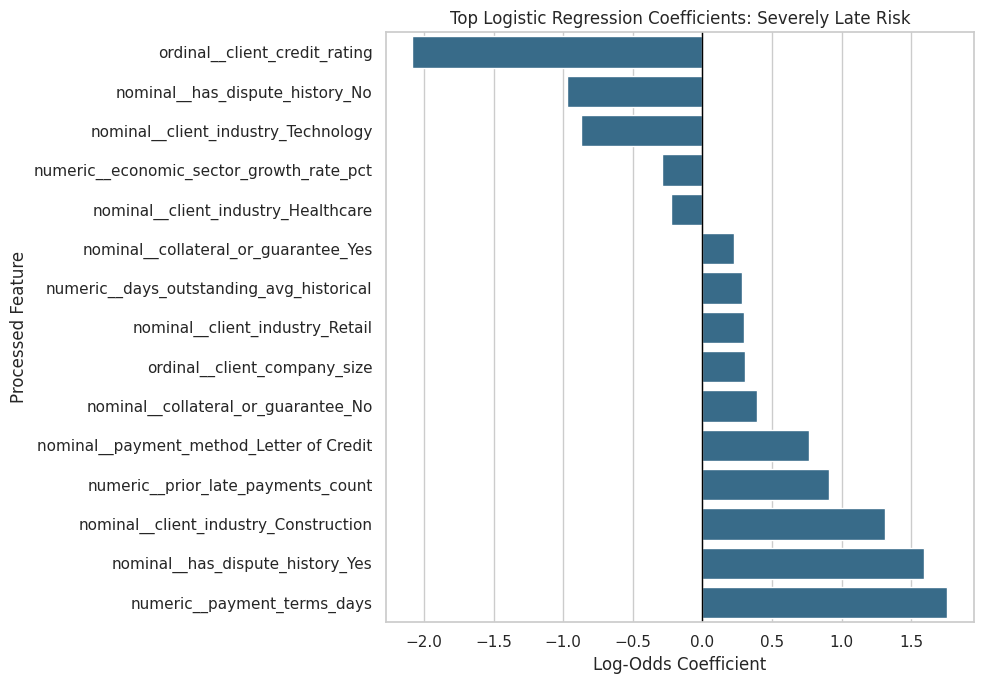

In [36]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline

y_train_severely_late = (
    y_train == "Severely Late"
).astype(int)

binary_explainability_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        (
            "model",
            LogisticRegression(
                C=100.0,
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE
            ),
        ),
    ]
)

binary_explainability_pipeline.fit(
    X_train_selected,
    y_train_severely_late
)

binary_feature_names = (
    binary_explainability_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

binary_logistic_model = (
    binary_explainability_pipeline
    .named_steps["model"]
)

log_odds_coefficients = binary_logistic_model.coef_[0]

odds_ratio_results = pd.DataFrame(
    {
        "feature": binary_feature_names,
        "log_odds_coefficient": log_odds_coefficients,
        "odds_ratio": np.exp(log_odds_coefficients),
    }
)

odds_ratio_results["absolute_log_odds"] = (
    odds_ratio_results["log_odds_coefficient"].abs()
)

odds_ratio_results = odds_ratio_results.sort_values(
    "absolute_log_odds",
    ascending=False
)

display(odds_ratio_results.round(4))

top_odds_ratio_features = (
    odds_ratio_results
    .head(15)
    .sort_values("log_odds_coefficient")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_odds_ratio_features,
    x="log_odds_coefficient",
    y="feature",
    color="#2A6F97"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Top Logistic Regression Coefficients: Severely Late Risk"
)

plt.xlabel("Log-Odds Coefficient")
plt.ylabel("Processed Feature")

plt.tight_layout()
plt.show()

**Interpretation of Logistic Regression Odds Ratios**

This odds-ratio analysis focuses on whether an invoice is `Severely Late` rather than On-Time or Late. It uses a binary Logistic Regression model with the same selected features, preprocessing approach, regularization value, and class-weighting strategy as the final model.

`client_credit_rating` has the largest absolute coefficient. The credit-rating categories were ordinal encoded from Poor to Excellent. Its odds ratio is 0.1247, which means that moving up one credit-rating level is associated with lower odds of an invoice being Severely Late, while the other features are held constant.

`payment_terms_days` has an odds ratio of 5.8006. Since numeric variables were standardized, this means that a one-standard-deviation increase in payment terms is associated with substantially higher odds of an invoice being Severely Late.

`has_dispute_history_Yes` has an odds ratio of 4.9036. This suggests that invoices from clients with a dispute history are associated with higher odds of being Severely Late. `client_industry_Construction` also has a positive association, with an odds ratio of 3.7177.

`prior_late_payments_count` has an odds ratio of 2.4801. This suggests that clients with more previous late payments are associated with higher odds of an invoice being Severely Late. `payment_method_Letter of Credit` also has a positive association, with an odds ratio of 2.1436.

`collateral_or_guarantee_No` has an odds ratio of 1.4823, suggesting a positive association with Severely Late risk. However, the missing-value indicator for `guarantee_value_kes` has an odds ratio close to 1. This means that, after considering the other variables, the missing indicator alone provides little additional information to this explanatory model.

`economic_sector_growth_rate_pct` has an odds ratio of 0.7466. This suggests that invoices in faster-growing sectors are associated with lower odds of being Severely Late.

These odds ratios show associations learned by the model. They do not prove that a feature causes an invoice to be paid late.

### Permutation Feature Importance

Permutation feature importance measures how much the final model's macro F1-score changes when the values of one original input feature are randomly shuffled.

If shuffling a feature causes a large decrease in macro F1-score, that feature is important for the model's predictions. A feature with an importance close to zero provides little unique predictive information after the other features are considered.

This analysis uses the untouched test dataset only after the final model has been selected. It does not retrain, resample, or alter the test data.

,feature,importance_mean,importance_std
9,client_credit_rating,0.1767,0.0398
0,payment_terms_days,0.1430,0.0186
3,prior_late_payments_count,0.1018,0.0209
8,client_industry,0.0441,0.0138
12,has_dispute_history,0.0293,0.0156
5,days_outstanding_avg_historical,0.0176,0.0129
13,collateral_or_guarantee,0.0055,0.0065
1,invoice_amount_kes,0.0047,0.0083
2,client_relationship_years,0.0033,0.0067
6,guarantee_value_kes,-0.0010,0.0082


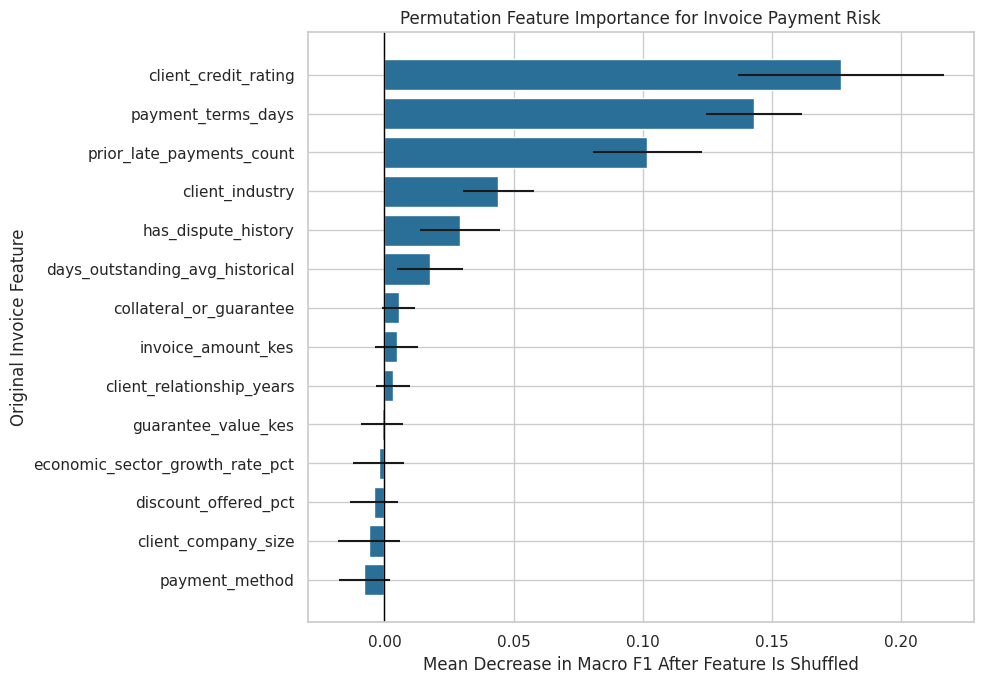

In [37]:
from sklearn.inspection import permutation_importance

permutation_result = permutation_importance(
    final_pipeline,
    X_test_selected,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_results = pd.DataFrame(
    {
        "feature": X_test_selected.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
).sort_values(
    "importance_mean",
    ascending=False
)

display(permutation_importance_results.round(4))

permutation_plot = permutation_importance_results.sort_values(
    "importance_mean",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    permutation_plot["feature"],
    permutation_plot["importance_mean"],
    xerr=permutation_plot["importance_std"],
    color="#2A6F97"
)

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Permutation Feature Importance for Invoice Payment Risk"
)

plt.xlabel(
    "Mean Decrease in Macro F1 After Feature Is Shuffled"
)

plt.ylabel("Original Invoice Feature")

plt.tight_layout()
plt.show()

**Interpretation of Permutation Feature Importance**

`client_credit_rating` is the most important feature for the final model, with a mean importance of 0.1767. Shuffling credit-rating values causes the largest decrease in macro F1-score, showing that client credit rating provides important information for predicting payment risk.

`payment_terms_days` is the second most important feature, with an importance value of 0.1430. This supports the earlier ANOVA results and boxplots, which showed that longer payment terms are associated with higher payment risk.

`prior_late_payments_count` is the third most important feature, with an importance value of 0.1018. This shows that a client's history of late payments is useful for predicting whether a current invoice will be On-Time, Late, or Severely Late.

`client_industry` and `has_dispute_history` also contribute useful information, with importance values of 0.0441 and 0.0293 respectively. `days_outstanding_avg_historical` has a smaller positive importance value of 0.0176.

The remaining variables have importance values close to zero. This means that they provide little unique predictive information after the other variables are considered. Small negative importance values should be interpreted cautiously because they may be due to random variation in the permutation process rather than evidence that a feature is harmful.

The permutation-importance results agree with the odds-ratio analysis. Client credit rating, payment terms, dispute history, and prior late payments are consistently important for predicting payment risk. These results show associations learned by the model and do not prove causation.

## 12. Model Persistence and New-Invoice Prediction

The final tuned Logistic Regression pipeline is saved so that it can be reused to predict the payment risk of new invoices.

The saved pipeline includes the preprocessing steps and the fitted classification model. It applies the same handling of guarantee values, categorical encoding, ordinal encoding, and numeric scaling used during model training.

The final model uses class weighting rather than resampling. Therefore, no synthetic records are created when making predictions for new invoices.

In [38]:
import joblib

model_path = (
    "d10_invoice_payment_risk_"
    "tuned_logistic_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    model_path
)

loaded_pipeline = joblib.load(
    model_path
)

print(
    "Full classification pipeline saved and reloaded:"
)

print(model_path)

print(
    "\nPipeline steps:",
    list(loaded_pipeline.named_steps.keys())
)

print(
    "Balancing configuration:",
    loaded_pipeline.named_steps["resampler"]
)

Full classification pipeline saved and reloaded:
d10_invoice_payment_risk_tuned_logistic_pipeline.joblib

Pipeline steps: ['preprocessor', 'resampler', 'model']
Balancing configuration: passthrough


In [39]:
new_invoice = pd.DataFrame(
    [
        {
            "payment_terms_days": 60,
            "invoice_amount_kes": 550000.0,
            "client_relationship_years": 3.0,
            "prior_late_payments_count": 3,
            "discount_offered_pct": 1.5,
            "days_outstanding_avg_historical": 38.0,
            "guarantee_value_kes": np.nan,
            "economic_sector_growth_rate_pct": 1.8,
            "client_industry": "Construction",
            "client_credit_rating": "Fair",
            "client_company_size": "Medium",
            "payment_method": "Bank Transfer",
            "has_dispute_history": "Yes",
            "collateral_or_guarantee": "No",
        }
    ]
)

new_invoice = new_invoice[
    X_train_selected.columns
].copy()

assert (
    new_invoice.columns.tolist()
    == X_train_selected.columns.tolist()
)

predicted_payment_risk = loaded_pipeline.predict(
    new_invoice
)

predicted_probabilities = loaded_pipeline.predict_proba(
    new_invoice
)[0]

model_classes = loaded_pipeline.named_steps[
    "model"
].classes_

print(
    "Predicted payment-risk category:",
    predicted_payment_risk[0]
)

print("\nPredicted probabilities:")

for payment_risk_class, probability in zip(
    model_classes,
    predicted_probabilities
):
    print(
        f"{payment_risk_class}: "
        f"{probability:.4f}"
    )

print(
    f"\nInput invoice rows: {len(new_invoice)}"
)

print(
    f"Prediction rows returned: "
    f"{len(predicted_payment_risk)}"
)

print(
    "Resampling at inference:",
    loaded_pipeline.named_steps["resampler"]
)

Predicted payment-risk category: Severely Late

Predicted probabilities:
Late: 0.0191
On-Time: 0.0001
Severely Late: 0.9808

Input invoice rows: 1
Prediction rows returned: 1
Resampling at inference: passthrough


**Interpretation of Model Persistence and New-Invoice Prediction**

The complete classification pipeline was saved as `d10_invoice_payment_risk_tuned_logistic_pipeline.joblib` and then reloaded successfully. The saved pipeline contains the preprocessing steps, the balancing configuration, and the tuned Logistic Regression model.

The reloaded pipeline predicted the new invoice as `Severely Late`. The model assigned a probability of 0.9808 to the Severely Late category, compared with 0.0191 for Late and 0.0001 for On-Time.

This prediction is consistent with the model's learned associations because the invoice has a Fair credit rating, a 60-day payment term, three prior late payments, a dispute history, and no collateral or guarantee.

The pipeline received one new invoice and returned one prediction. Its resampling step is `passthrough`, confirming that the final model uses class weighting rather than generating synthetic records. The predicted probability is a model estimate and should be used to support review decisions rather than treated as a guaranteed payment outcome.